# Phase 4 — Model Predictive Control (MPC)

### In this phase we move from heuristic battery dispatch to formal optimization.
- The goal is to design a battery controller that decides actions over a future horizon,
rather than reacting only to the current hour.

- We begin with deterministic MPC, then extend it to uncertainty-aware MPC.

This phase answers a central question of the project:
* How should limited storage be scheduled over time when future system stress is uncertain?

### In Phase 3 we built:
- a greedy baseline,
- a horizon-based heuristic baseline,
- and a simple battery model with state of charge dynamics.

Those controllers were useful, but still heuristic.
They did not solve an explicit optimization problem.

So Phase 4 introduces MPC:
- optimize battery actions over a horizon,
- apply only the first action,
- move forward one hour,
- solve again.

This is the first controller in the project that is formally optimization-based.

In [39]:
import os
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = "../data/processed"

det_aggr = pd.read_csv(f"{DATA_DIR}/deterministic_mpc_aggressive_2025.csv", parse_dates=["utc_timestamp"])
det_bal = pd.read_csv(f"{DATA_DIR}/deterministic_mpc_balanced_2025.csv", parse_dates=["utc_timestamp"])
det_cons = pd.read_csv(f"{DATA_DIR}/deterministic_mpc_conservative_2025.csv", parse_dates=["utc_timestamp"])
ua_aggr = pd.read_csv(f"{DATA_DIR}/uncertainty_aware_mpc_aggressive_2025.csv", parse_dates=["utc_timestamp"])

det_aggr.head()

,utc_timestamp,hour,horizon_hours,objective_value,load_forecast_mw,solar_forecast_mw,wind_onshore_forecast_mw,wind_offshore_forecast_mw,forecast_net_load_mw,battery_charge_mw,battery_discharge_mw,battery_power_mw,soc_before_mwh,soc_after_mwh,net_load_after_battery_mw
0,2025-01-01 00:00:00+01:00,0,24,0.082983,44518.2425,0.0,38472.2225,3759.6575,2286.3625,0.155396,1.057791,0.902395,50.000000,49.034162,2285.460105
1,2025-01-01 01:00:00+01:00,1,24,0.081166,42269.3500,0.0,38931.1575,3795.0700,-456.8775,0.789778,0.758815,-0.030963,49.034162,48.985698,-456.846537
2,2025-01-01 02:00:00+01:00,2,24,0.081104,41095.9975,0.0,39388.8900,3826.1900,-2119.0825,1.111935,0.614359,-0.497577,48.985698,49.395343,-2118.584923
3,2025-01-01 03:00:00+01:00,3,24,0.079985,40805.1225,0.0,39347.5000,3336.8875,-1879.2650,0.917879,0.659305,-0.258574,49.395343,49.573322,-1879.006426
4,2025-01-01 04:00:00+01:00,4,24,0.083886,40678.0000,0.0,39681.4475,3213.5925,-2217.0400,1.157189,0.838330,-0.318859,49.573322,49.790198,-2216.721141


## What deterministic MPC optimizes

### Deterministic MPC formulation

State:
- SOC_t

Controls:
- P_t^ch >= 0
- P_t^dis >= 0

Battery power:
- P_t = P_t^dis - P_t^ch

Disturbance:
- forecast net load

Dynamics:
- SOC_{t+1} = SOC_t + eta_ch * P_t^ch * dt - (P_t^dis * dt) / eta_dis

Objective:
- minimize stress after battery action
- + penalize battery power
- + penalize SOC deviation from the midpoint

This gives a controller that looks ahead over 24 hours and chooses the first action from the optimized sequence.

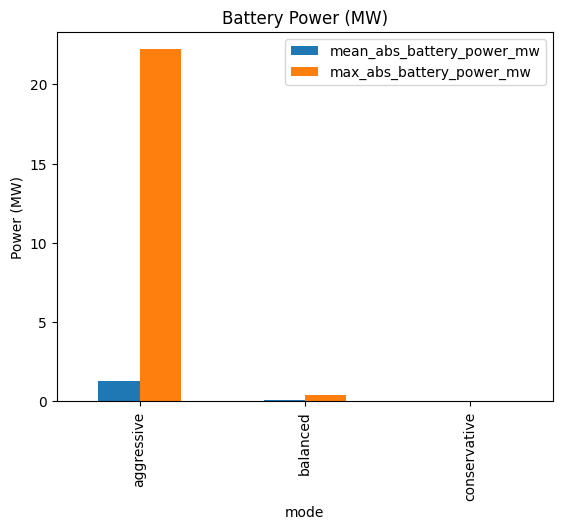

In [40]:
det_summary = pd.DataFrame({
    "mode": ["aggressive", "balanced", "conservative"],
    "mean_abs_battery_power_mw": [
        det_aggr["battery_power_mw"].abs().mean(),
        det_bal["battery_power_mw"].abs().mean(),
        det_cons["battery_power_mw"].abs().mean(),
    ],
    "max_abs_battery_power_mw": [
        det_aggr["battery_power_mw"].abs().max(),
        det_bal["battery_power_mw"].abs().max(),
        det_cons["battery_power_mw"].abs().max(),
    ],
    "soc_min_mwh": [
        det_aggr["soc_after_mwh"].min(),
        det_bal["soc_after_mwh"].min(),
        det_cons["soc_after_mwh"].min(),
    ],
    "soc_max_mwh": [
        det_aggr["soc_after_mwh"].max(),
        det_bal["soc_after_mwh"].max(),
        det_cons["soc_after_mwh"].max(),
    ],
})
 
det_summary.plot(x="mode", y=["mean_abs_battery_power_mw", "max_abs_battery_power_mw"], kind="bar")
plt.title("Battery Power (MW)")
plt.ylabel("Power (MW)")
plt.show()

## Deterministic MPC sensitivity study

We tested three objective-weight settings:

1. Aggressive
   - prioritizes stress reduction
   - allows stronger battery movement

2. Balanced
   - intermediate behavior

3. Conservative
   - penalizes battery movement more strongly
   - tends to preserve the battery and act less

What we learned:
- the optimizer itself is not the whole story,
- the objective function strongly shapes controller behavior,
- the same MPC structure can act very differently depending on the cost design.
"""

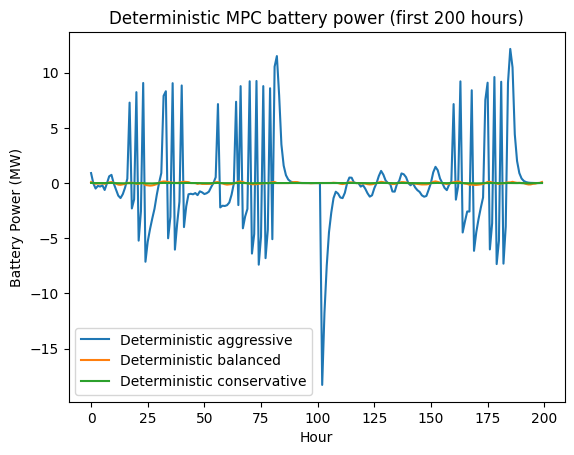

In [41]:
window = slice(0, 200)

plt.figure()
plt.plot(det_aggr["battery_power_mw"][window], label="Deterministic aggressive")
plt.plot(det_bal["battery_power_mw"][window], label="Deterministic balanced")
plt.plot(det_cons["battery_power_mw"][window], label="Deterministic conservative")
plt.legend()
plt.title("Deterministic MPC battery power (first 200 hours)")
plt.ylabel("Battery Power (MW)")
plt.xlabel("Hour")
plt.show()

## Interpretation

- The three deterministic controllers have the same model and the same data,
but different optimization weights.

- This means the differences above are not caused by the solver or by the battery model. They are caused by the control objective itself.

- This is an important result: objective design changes controller attitude.

### Limitation of deterministic MPC

- Deterministic MPC only reacts to forecast net load.

- But earlier phases showed that:
    - forecast errors are structured,
    - uncertainty is not constant through the day,
    - different variables contribute different levels of forecast risk.

- So deterministic MPC still ignores an important part of the problem: 
    - future uncertainty.

- That motivates the next step: Uncertainty-aware MPC.

- The uncertainty-aware controller keeps the same battery model, the same horizon and the same optimization structure. The key difference is the optimized signal.

- Instead of using only:

    - forecast_net_load

- it uses:

    - risk_adjusted_net_load = forecast_net_load + reserve_margin

where reserve_margin comes from the hourly uncertainty profile built in Phase 2.
So the controller becomes more cautious in hours where historical forecast uncertainty is larger.

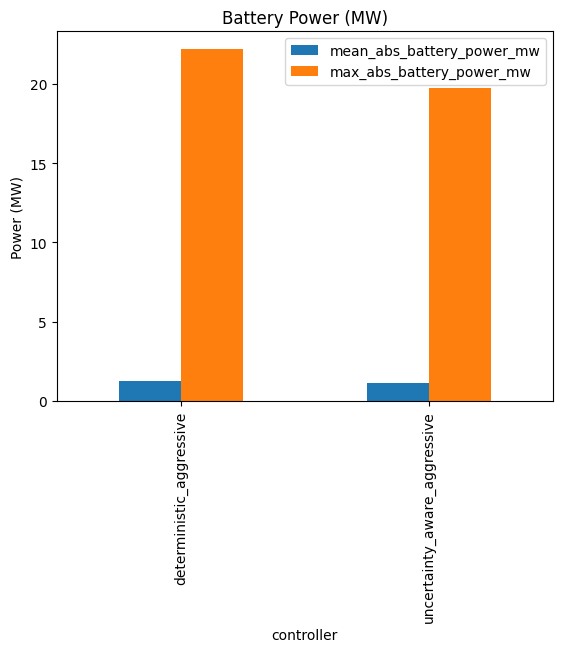

In [42]:
compare_summary = pd.DataFrame({
    "controller": ["deterministic_aggressive", "uncertainty_aware_aggressive"],
    "mean_abs_battery_power_mw": [
        det_aggr["battery_power_mw"].abs().mean(),
        ua_aggr["battery_power_mw"].abs().mean(),
    ],
    "max_abs_battery_power_mw": [
        det_aggr["battery_power_mw"].abs().max(),
        ua_aggr["battery_power_mw"].abs().max(),
    ],
    "soc_min_mwh": [
        det_aggr["soc_after_mwh"].min(),
        ua_aggr["soc_after_mwh"].min(),
    ],
    "soc_max_mwh": [
        det_aggr["soc_after_mwh"].max(),
        ua_aggr["soc_after_mwh"].max(),
    ],
})

compare_summary.plot(x="controller", y=["mean_abs_battery_power_mw", "max_abs_battery_power_mw"], kind="bar")
plt.title("Battery Power (MW)")
plt.ylabel("Power (MW)")
plt.show()

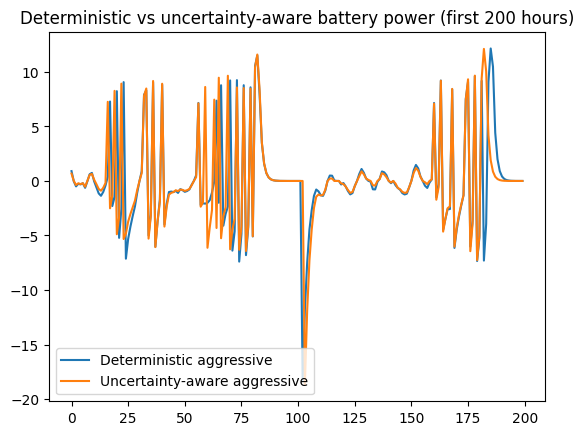

In [43]:
plt.figure()
plt.plot(det_aggr["battery_power_mw"][window], label="Deterministic aggressive")
plt.plot(ua_aggr["battery_power_mw"][window], label="Uncertainty-aware aggressive")
plt.legend()
plt.title("Deterministic vs uncertainty-aware battery power (first 200 hours)")
plt.show()

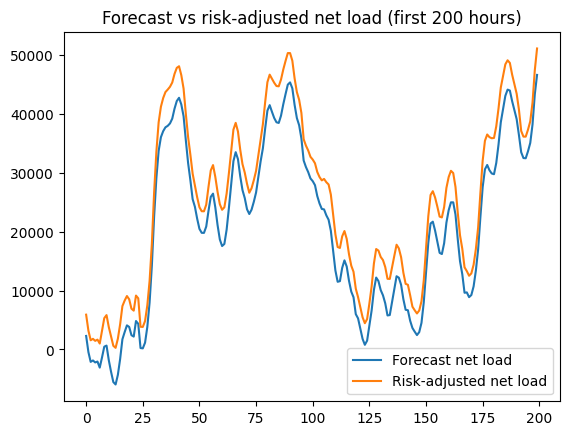

In [44]:
plt.figure()
plt.plot(ua_aggr["forecast_net_load_mw"][window], label="Forecast net load")
plt.plot(ua_aggr["risk_adjusted_net_load_mw"][window], label="Risk-adjusted net load")
plt.legend()
plt.title("Forecast vs risk-adjusted net load (first 200 hours)")
plt.show()

## What changed with uncertainty-aware MPC

- Using risk-adjusted net load means the controller no longer reacts only to the forecasted stress.

- Instead, it reacts to:
    - forecasted stress
    - plus a reserve margin derived from historical hourly uncertainty

- This makes the controller more cautious in riskier hours.

- In practice, this produced stronger and more meaningful battery usethan the deterministic controller with the same aggressive weights.

In [45]:
ua_aggr[[
    "utc_timestamp",
    "forecast_net_load_mw",
    "reserve_margin_mw",
    "risk_adjusted_net_load_mw",
    "battery_power_mw",
    "soc_before_mwh",
    "soc_after_mwh",
    "net_load_after_battery_mw",
]].head(12)

,utc_timestamp,forecast_net_load_mw,reserve_margin_mw,risk_adjusted_net_load_mw,battery_power_mw,soc_before_mwh,soc_after_mwh,net_load_after_battery_mw
0,2025-01-01 00:00:00+01:00,2286.3625,3617.732264,5904.094764,0.674154,50.000000,49.290362,5903.420610
1,2025-01-01 01:00:00+01:00,-456.8775,3641.423966,3184.546466,0.004671,49.290362,49.270173,3184.541795
2,2025-01-01 02:00:00+01:00,-2119.0825,3675.067769,1555.985269,-0.372844,49.270173,49.624362,1556.358114
3,2025-01-01 03:00:00+01:00,-1879.2650,3674.782901,1795.517901,-0.215559,49.624362,49.811292,1795.733460
4,2025-01-01 04:00:00+01:00,-2217.0400,3669.210252,1452.170252,-0.289167,49.811292,50.069789,1452.459420
5,2025-01-01 05:00:00+01:00,-2062.7200,3724.142174,1661.422174,-0.206907,50.069789,50.266431,1661.629081
6,2025-01-01 06:00:00+01:00,-3097.6075,4092.006123,994.398623,-0.529801,50.266431,50.767314,994.928424
7,2025-01-01 07:00:00+01:00,-1371.3450,4494.939701,3123.594701,0.016585,50.767314,50.749836,3123.578116
8,2025-01-01 08:00:00+01:00,463.2275,4851.495290,5314.722790,0.553172,50.749836,50.167550,5314.169618
9,2025-01-01 09:00:00+01:00,649.0375,5181.305191,5830.342691,0.645750,50.167550,49.487805,5829.696941


### Difficulties faced in Phase 4

1. Solver cost

    - Moving from heuristic rules to MPC required solving an optimization problem at every hour over the full year. This made runtime much larger than in earlier phases.

2. Scaling mismatch

    - The battery is small relative to German-scale net load. As a result, some weight choices made the optimizer nearly inactive.

3. Objective tuning

    - The first deterministic MPC setup was too passive. This revealed that controller behavior depends strongly on the objective weights.

4. Typing and implementation detail

    -.The MPC implementation required cleaning several solver-output and typing issues before the file became stable and easy to extend.

# Where Phase 4_A takes the project next

- We now have:
    - heuristic baselines,
    - deterministic MPC,
    - uncertainty-aware MPC.

- This gives the project a complete control ladder:

*greedy -> horizon heuristic -> deterministic MPC -> uncertainty-aware MPC*

- The natural next direction is not to rebuild everything, but to compare these controllers carefully and understand the trade-offs.

- Possible future extensions include:
    - stronger uncertainty constraints,
    - degradation-aware penalties,
    - capacity sensitivity studies,
    - market-aware objectives.

- But even without those extensions, the project now already demonstrates meaningful uncertainty-aware control design.